# Market Technical Indicators

Calculate the established technical-indicator feature table from the observed AAPL dollar bars. Existing features are reused so repeated notebook runs do not repeat the calculation.

## Process the Data

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_preprocessing.market_technical_indicators import (
    save_market_technical_indicators,
)

PROJECT_ROOT = Path.cwd().resolve().parents[1]
feature_dir = PROJECT_ROOT / "data/research_data/market/features"
period = "2025-01-01_2025-12-31"
dollar_bar_path = feature_dir / f"aapl_dollar_bar_{period}.parquet"
technical_path = feature_dir / f"aapl_dollar_bar_technical_{period}.parquet"

if not technical_path.is_file():
    save_market_technical_indicators(
        data_path=dollar_bar_path,
        window=14,
        output_path=technical_path,
    )

technical_features = pd.read_parquet(technical_path)
identifier_columns = ["start", "end", "symbol"]
feature_columns = [
    column for column in technical_features.columns
    if column not in identifier_columns
]
technical_path

PosixPath('/Users/kwonjunhyuk9/Documents/financial-machine-learning/data/research_data/market/features/aapl_dollar_bar_technical_2025-01-01_2025-12-31.parquet')

## Take a Quick Look at the Data Structure

In [8]:
technical_features.head()

,start,end,symbol,McClellan Oscillator,Advancers - Decliners,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator,New Highs - New Lows,Money Flow Index,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
0,2025-01-02 13:45:58.902948+00:00,2025-01-02 14:30:01.004279+00:00,AAPL,0.0000,0.00,0.0,-2037.819820,0.0000,0,NaN,...,NaN,NaN,1.110,1.1100,251.1300,248.9100,246.6900,NaN,NaN,NaN
1,2025-01-02 14:30:01.004306+00:00,2025-01-02 14:30:02.119118+00:00,AAPL,12.4325,248.65,-2059.0,-3626.191248,-505.3909,-1,NaN,...,NaN,NaN,0.350,0.7300,250.3353,248.8753,247.4153,NaN,NaN,NaN
2,2025-01-02 14:30:02.129080+00:00,2025-01-02 14:30:02.891073+00:00,AAPL,22.9971,248.59,-4072.0,-5639.191248,-1306.6971,-1,NaN,...,NaN,NaN,0.125,0.5283,249.8940,248.8373,247.7806,NaN,NaN,NaN
3,2025-01-02 14:30:02.929026+00:00,2025-01-02 14:30:04.394582+00:00,AAPL,31.9159,248.61,-2054.0,-6311.857915,-1729.7438,0,NaN,...,NaN,NaN,0.150,0.4338,249.6745,248.8070,247.9395,NaN,NaN,NaN
4,2025-01-02 14:30:04.394604+00:00,2025-01-02 14:30:05.084156+00:00,AAPL,39.3804,248.58,-4066.0,-6982.524582,-1958.9529,-1,NaN,...,NaN,NaN,0.060,0.3590,249.4947,248.7767,248.0587,NaN,NaN,NaN


In [9]:
technical_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 156779 entries, 0 to 156778
Data columns (total 54 columns):
 #   Column                                    Non-Null Count   Dtype              
---  ------                                    --------------   -----              
 0   start                                     156779 non-null  datetime64[us, UTC]
 1   end                                       156779 non-null  datetime64[us, UTC]
 2   symbol                                    156779 non-null  str                
 3   McClellan Oscillator                      156779 non-null  float64            
 4   Advancers - Decliners                     156779 non-null  float64            
 5   On-Balance Volume                         156779 non-null  float64            
 6   Accumulation/Distribution Line            156779 non-null  float64            
 7   Chaikin Oscillator                        156779 non-null  float64            
 8   New Highs - New Lows                      156779 non-nu

In [10]:
technical_features["symbol"].value_counts(dropna=False)

symbol
AAPL    156779
Name: count, dtype: int64

In [11]:
technical_features[feature_columns].describe()

,McClellan Oscillator,Advancers - Decliners,On-Balance Volume,Accumulation/Distribution Line,Chaikin Oscillator,New Highs - New Lows,Money Flow Index,Williams %R,Aroon Indicator Up,Aroon Indicator Down,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
count,156779.000000,156779.000000,1.567790e+05,1.567790e+05,156779.000000,156779.000000,156766.000000,156765.000000,156766.000000,156766.000000,...,156766.000000,156766.000000,156779.000000,156779.000000,156779.000000,156779.000000,156779.000000,156766.000000,156766.000000,156766.000000
mean,0.014968,223.984731,1.264303e+06,2.426773e+06,102.796228,0.005115,50.465758,-49.349642,54.167544,54.687016,...,233.297583,232.916299,0.160212,0.160231,233.619329,233.298867,232.978406,233.662197,233.294747,232.927298
std,5.016509,53.039303,5.983556e+05,1.107304e+06,1812.821028,0.266299,16.074831,32.879199,34.590463,34.557846,...,28.206046,28.274481,0.172576,0.090434,28.154074,28.204605,28.256203,28.145663,28.205326,28.268432
min,-56.450800,0.000000,-2.565300e+04,-3.086267e+04,-21701.876700,-1.000000,0.000000,-100.000000,7.142900,7.142900,...,169.548900,168.539500,0.000000,0.000000,169.848700,169.566300,169.207300,169.770000,169.542500,168.620000
25%,-0.719800,206.182500,7.879315e+05,1.639780e+06,-1097.029500,0.000000,38.840025,-80.000000,21.428600,21.428600,...,209.594575,209.123175,0.080000,0.105000,209.933450,209.585600,209.233750,210.000000,209.573125,209.160000
50%,1.087400,230.250000,1.326645e+06,2.613935e+06,110.901500,0.000000,50.081850,-49.006600,57.142900,57.142900,...,231.678600,231.258150,0.130000,0.143900,232.039100,231.671500,231.324500,232.090000,231.665000,231.270000
75%,2.553700,256.100000,1.528218e+06,3.136711e+06,1287.736100,0.000000,62.916150,-18.367300,92.857100,92.857100,...,257.194950,256.838850,0.200000,0.195000,257.498300,257.181900,256.890300,257.555000,257.190000,256.860000
max,64.434100,288.520000,2.664144e+06,4.527541e+06,26109.122500,1.000000,100.000000,-0.000000,100.000000,100.000000,...,287.981400,287.771300,13.990000,3.256400,288.584800,287.971500,287.727900,288.610000,287.967500,287.700000


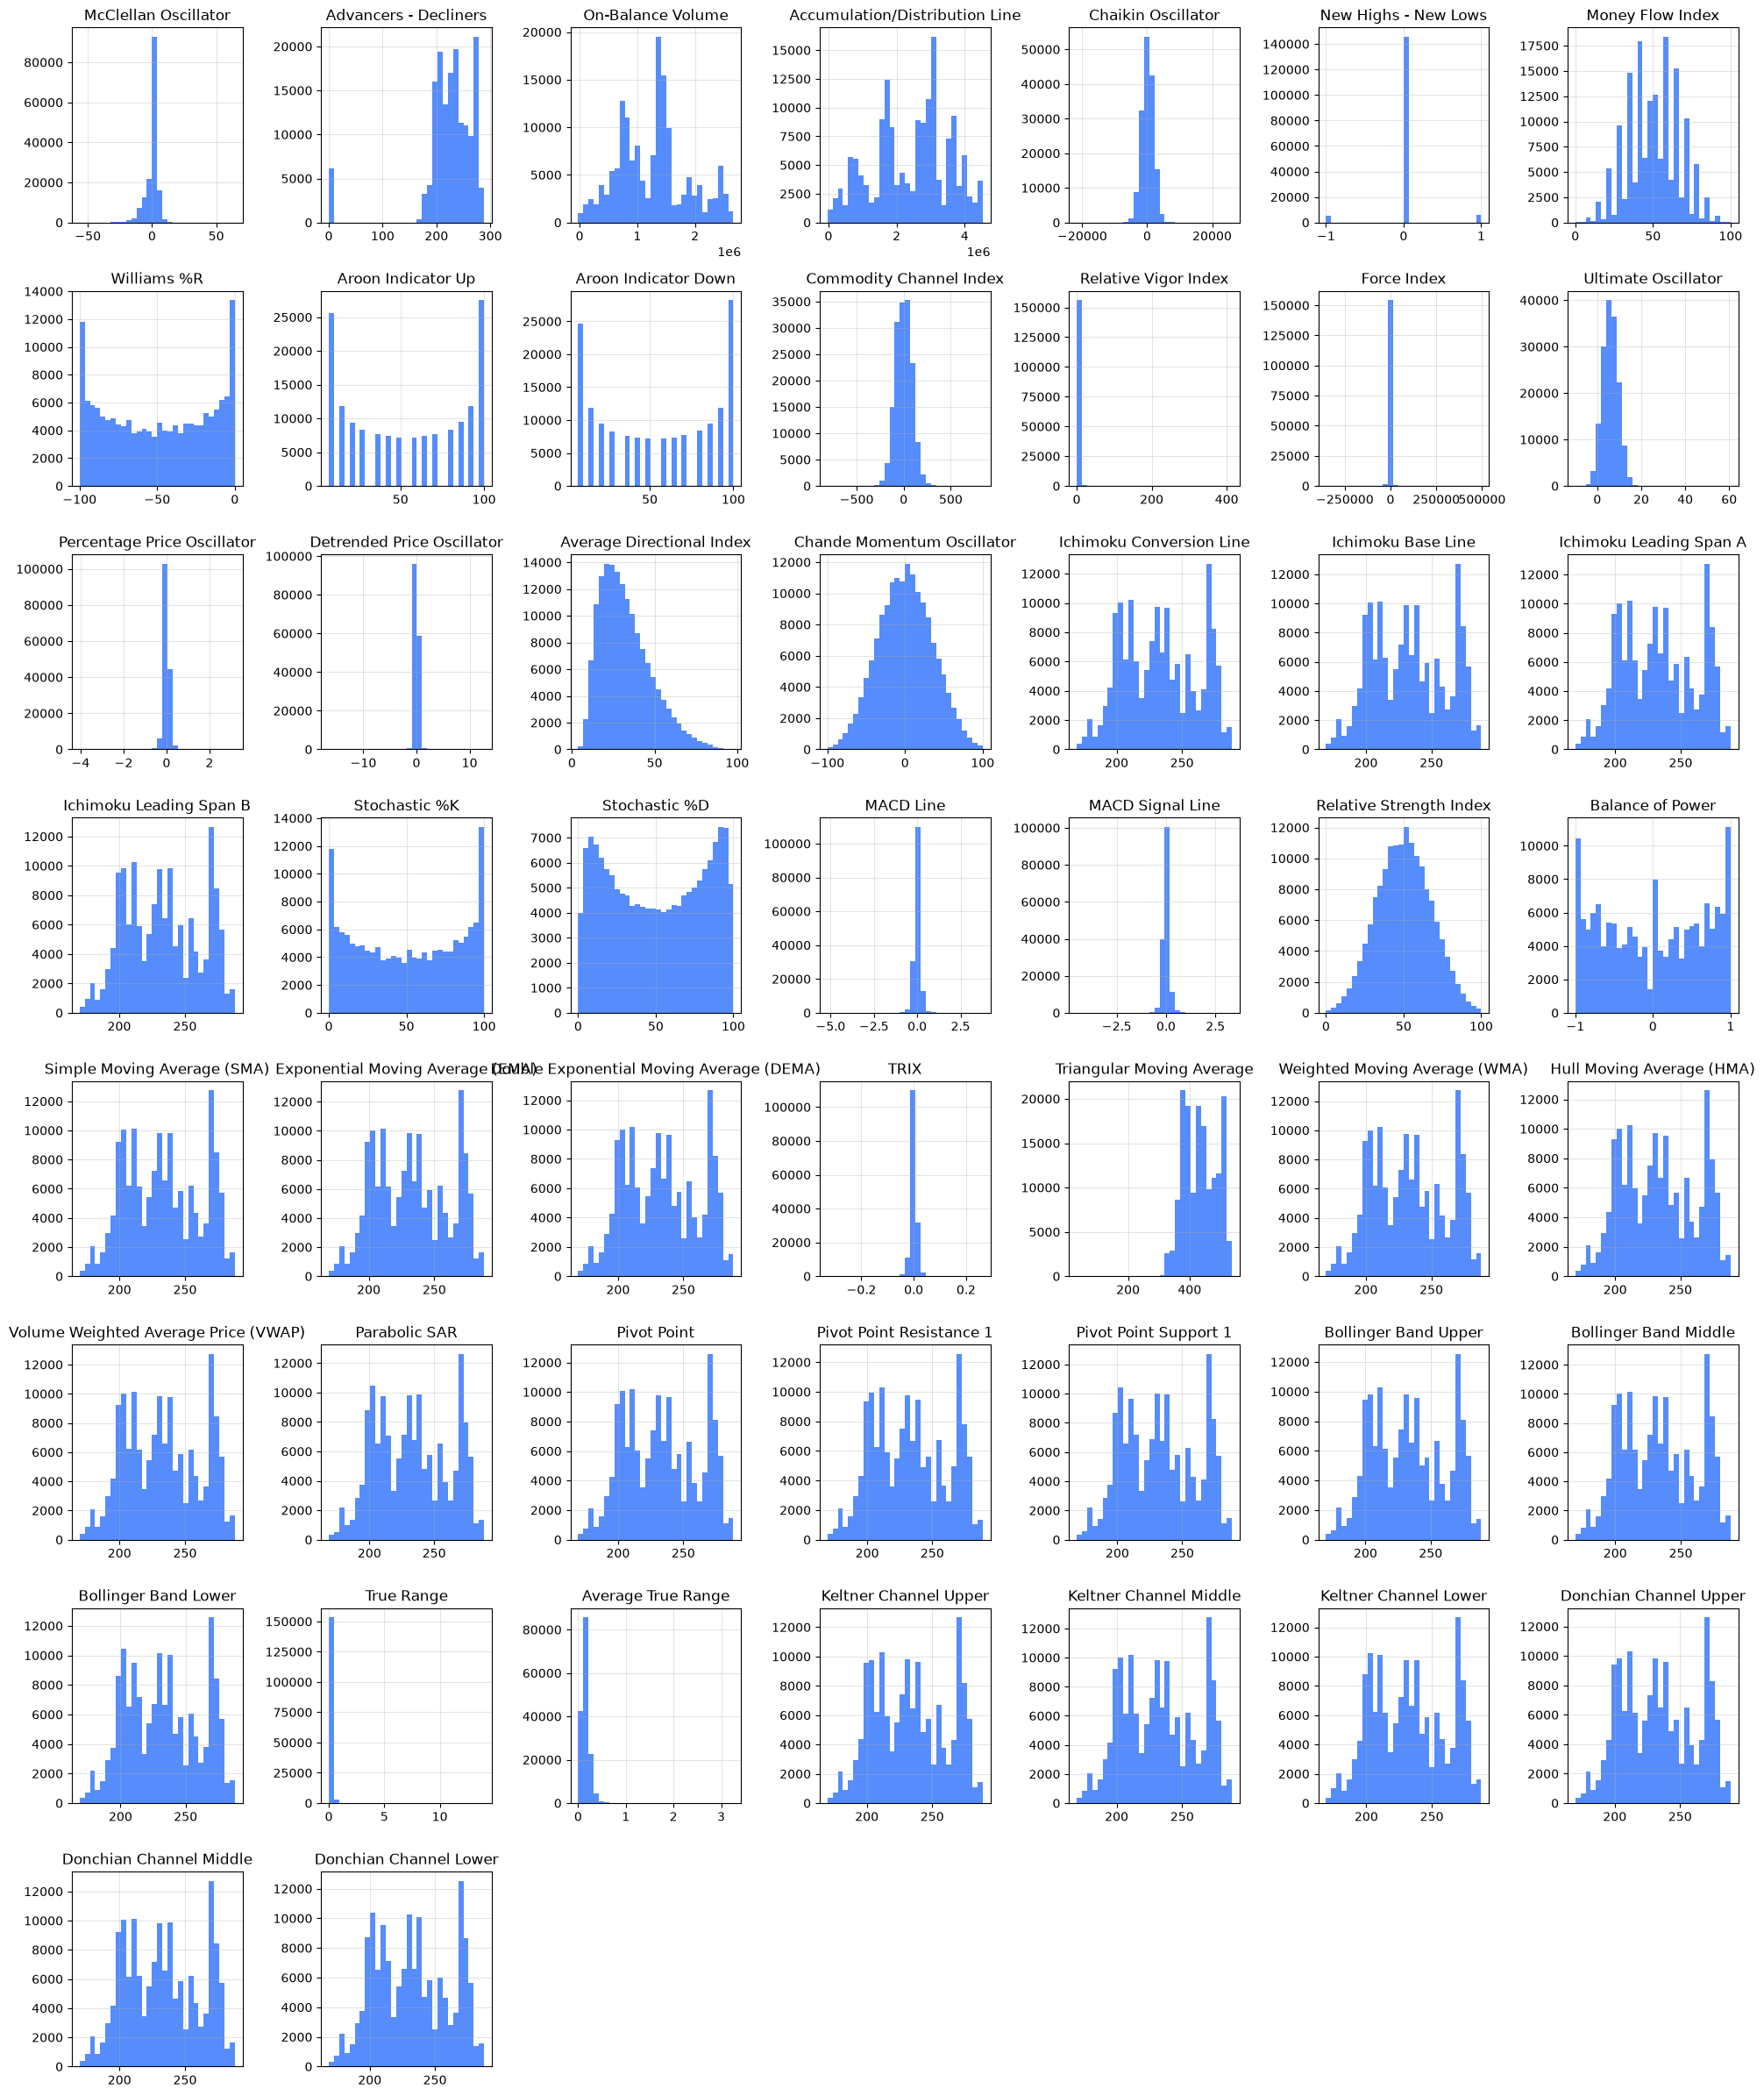

In [12]:
technical_features[feature_columns].replace(
    [np.inf, -np.inf], np.nan
).hist(bins=30, figsize=(20, 24))
plt.tight_layout()
plt.show()